In [181]:
from bs4 import BeautifulSoup
import requests

In [182]:
import pandas as pd
import webbrowser

In [183]:
print("Hello")

Hello


In [184]:
url = "https://books.toscrape.com/"

In [185]:
webbrowser.open(url)

False

In [186]:
response = requests.get(url)

In [187]:
response

<Response [200]>

In [188]:
response.content

b'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" hre

In [189]:
Headers = {"User-Agent" : "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36"}

In [190]:
response = requests.get(url,headers = Headers)

In [191]:
content = response.content

In [192]:
print(content)

b'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" hre

In [193]:
soup = BeautifulSoup(content,'lxml')

In [194]:
articletags = soup.find_all('article',class_="product_pod")

In [195]:
data = []

In [196]:
for tag in articletags:
    book = tag.find('h3').find('a').text
    price = tag.find('p',class_='price_color').text
    rating = tag.find('p',class_="star-rating")["class"][1]
    image = tag.find("img")["src"]

    #self note to me []. helps to access the values inside the tag itself here img is the tag and there is value inside that called src

    data.append({
        "name" : book,
        "price" : price,
        "rating" : rating,
        "image" : image
    })



In [197]:
data

[{'name': 'A Light in the ...',
  'price': '£51.77',
  'rating': 'Three',
  'image': 'media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg'},
 {'name': 'Tipping the Velvet',
  'price': '£53.74',
  'rating': 'One',
  'image': 'media/cache/26/0c/260c6ae16bce31c8f8c95daddd9f4a1c.jpg'},
 {'name': 'Soumission',
  'price': '£50.10',
  'rating': 'One',
  'image': 'media/cache/3e/ef/3eef99c9d9adef34639f510662022830.jpg'},
 {'name': 'Sharp Objects',
  'price': '£47.82',
  'rating': 'Four',
  'image': 'media/cache/32/51/3251cf3a3412f53f339e42cac2134093.jpg'},
 {'name': 'Sapiens: A Brief History ...',
  'price': '£54.23',
  'rating': 'Five',
  'image': 'media/cache/be/a5/bea5697f2534a2f86a3ef27b5a8c12a6.jpg'},
 {'name': 'The Requiem Red',
  'price': '£22.65',
  'rating': 'One',
  'image': 'media/cache/68/33/68339b4c9bc034267e1da611ab3b34f8.jpg'},
 {'name': 'The Dirty Little Secrets ...',
  'price': '£33.34',
  'rating': 'Four',
  'image': 'media/cache/92/27/92274a95b7c251fea59a2b8a78275ab4.jpg'

In [198]:
df = pd.DataFrame(data)

In [199]:
print(df)

                                     name   price rating  \
0                      A Light in the ...  £51.77  Three   
1                      Tipping the Velvet  £53.74    One   
2                              Soumission  £50.10    One   
3                           Sharp Objects  £47.82   Four   
4            Sapiens: A Brief History ...  £54.23   Five   
5                         The Requiem Red  £22.65    One   
6            The Dirty Little Secrets ...  £33.34   Four   
7                 The Coming Woman: A ...  £17.93  Three   
8                     The Boys in the ...  £22.60   Four   
9                         The Black Maria  £52.15    One   
10  Starving Hearts (Triangular Trade ...  £13.99    Two   
11                  Shakespeare's Sonnets  £20.66   Four   
12                            Set Me Free  £17.46   Five   
13    Scott Pilgrim's Precious Little ...  £52.29   Five   
14                      Rip it Up and ...  £35.02   Five   
15                  Our Band Could Be ..

In [200]:
df["price"] = df["price"].str.replace("£","")

In [201]:
df["price"] = df["price"].astype(float)

In [202]:
print(df["price"])

0     51.77
1     53.74
2     50.10
3     47.82
4     54.23
5     22.65
6     33.34
7     17.93
8     22.60
9     52.15
10    13.99
11    20.66
12    17.46
13    52.29
14    35.02
15    57.25
16    23.88
17    37.59
18    51.33
19    45.17
Name: price, dtype: float64


In [203]:
df["price"].dtype

dtype('float64')

In [204]:
df.to_csv("books.csv",index=True)

In [205]:
import os

In [206]:
os.getcwd()

'/content'

In [207]:
os.listdir()

['.config', 'books.csv', 'sample_data']

In [208]:
df["price"].mean()

np.float64(38.048500000000004)

In [209]:
df.groupby("rating")["price"].mean()

,price
rating,
Five,39.750000
Four,31.105000
One,40.018333
Three,42.316667
Two,36.830000


In [210]:
df.loc[df["price"].idxmax()]

,15
name,Our Band Could Be ...
price,57.25
rating,Three
image,media/cache/54/60/54607fe8945897cdcced0044103b...


In [211]:
df.loc[df["price"].idxmin()]

,10
name,Starving Hearts (Triangular Trade ...
price,13.99
rating,Two
image,media/cache/be/f4/bef44da28c98f905a3ebec0b87be...


In [212]:
df["rating"].value_counts()

,count
rating,
One,6
Five,4
Four,4
Three,3
Two,3


In [213]:
df[df["price"] > 40]

,name,price,rating,image
0,A Light in the ...,51.77,Three,media/cache/2c/da/2cdad67c44b002e7ead0cc35693c...
1,Tipping the Velvet,53.74,One,media/cache/26/0c/260c6ae16bce31c8f8c95daddd9f...
2,Soumission,50.10,One,media/cache/3e/ef/3eef99c9d9adef34639f51066202...
3,Sharp Objects,47.82,Four,media/cache/32/51/3251cf3a3412f53f339e42cac213...
4,Sapiens: A Brief History ...,54.23,Five,media/cache/be/a5/bea5697f2534a2f86a3ef27b5a8c...
9,The Black Maria,52.15,One,media/cache/58/46/5846057e28022268153beff6d352...
13,Scott Pilgrim's Precious Little ...,52.29,Five,media/cache/94/b1/94b1b8b244bce9677c2f29ccc890...
15,Our Band Could Be ...,57.25,Three,media/cache/54/60/54607fe8945897cdcced0044103b...
18,Libertarianism for Beginners,51.33,Two,media/cache/0b/bc/0bbcd0a6f4bcd81ccb1049a52736...
19,It's Only the Himalayas,45.17,Two,media/cache/27/a5/27a53d0bb95bdd88288eaf66c923...


In [214]:
import matplotlib.pyplot as plt


In [215]:
rating_map = {
    "One" : 1,
    "Two" : 2,
    "Three" : 3,
    "Four" : 4,
    "Five" : 5,
}

In [216]:
df["rating"] = df["rating"].map(rating_map)

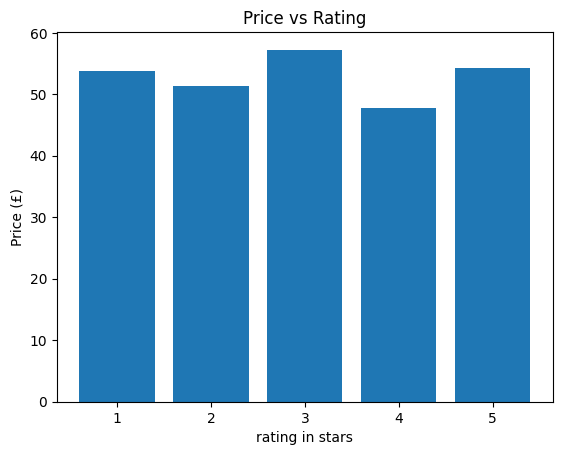

In [217]:
df_sorted = df.sort_values("rating")
plt.bar(df_sorted["rating"],df_sorted["price"])
plt.xlabel("rating in stars")
plt.ylabel("Price (£)")
plt.title("Price vs Rating")
plt.show()

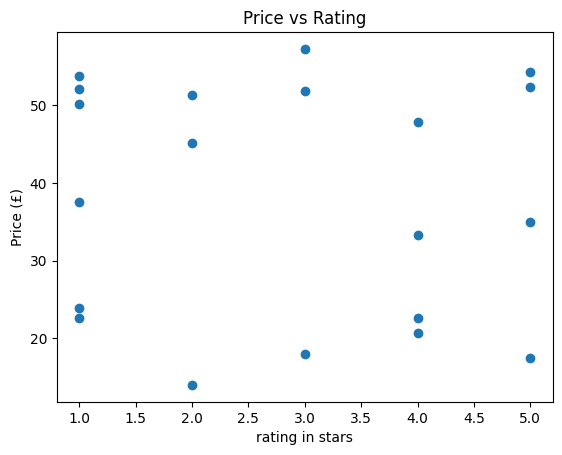

In [218]:
df_sorted = df.sort_values("rating")
plt.scatter(df_sorted["rating"],df_sorted["price"])
plt.xlabel("rating in stars")
plt.ylabel("Price (£)")
plt.title("Price vs Rating")
plt.show()

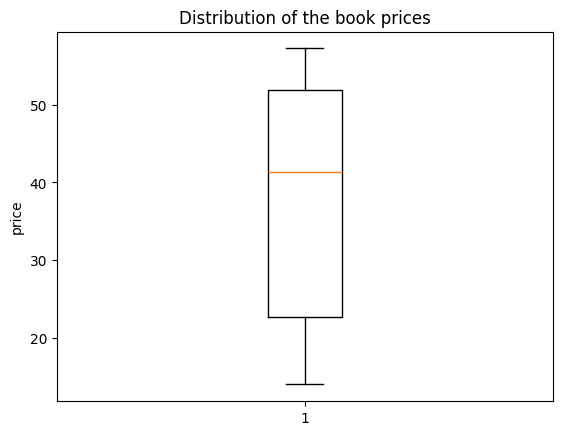

In [219]:
plt.boxplot(df["price"])

plt.ylabel("price")
plt.title("Distribution of the book prices")
plt.show()


Text(0.5, 1.0, 'Distribution of book prices')

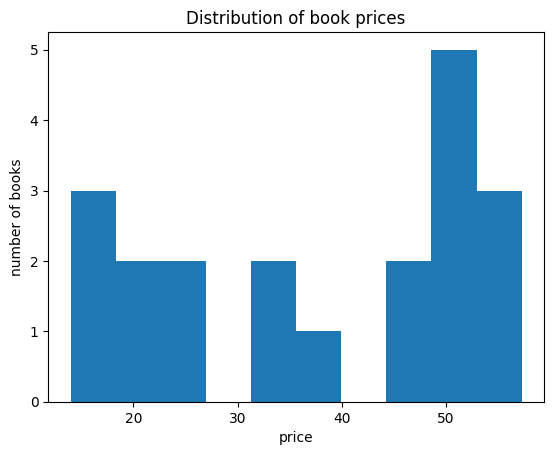

In [220]:
plt.hist(df["price"],bins = 10)

plt.xlabel("price")
plt.ylabel("number of books")

plt.title("Distribution of book prices")

In [221]:
# --------------------------- END OF ASSIGNMENT ---------------------------------------